In [35]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from statsmodels.tsa.stattools import adfuller, coint
import statsmodels.api as sm
from scipy.signal import lfilter
from statsmodels.tsa.vector_ar.vecm import coint_johansen
import yfinance as yf

### Why ADF alone isn't enough

In [36]:
rng = np.random.default_rng(42)
T = 2000

In [37]:
# x -> random walk
x = 100 + np.cumsum(rng.normal(0, 1, T))

# Stationart AR(1) noise
phi = 0.9
e = np.zeros(T)
eps = rng.normal(0, 1, T)
for t in range(1, T):
    e[t] = phi * e[t-1] + eps[t]

y = 10 + 2 * x + e

In [38]:
def adf_report(name, s, lags=1):
    stat, p, _, _, crit  = adfuller(s, maxlag=lags, regression="c", autolag=None)
    verdict = "STATIONARY" if stat < crit["5%"] else "non-stationary"
    print(f"{name:<16} stat={stat:8.3f}  p={p:.4f}  5% crit={crit['5%']:.3f}  -> {verdict}")


In [39]:
adf_report("x", x)
adf_report("y", y)

x                stat=   1.219  p=0.9961  5% crit=-2.863  -> non-stationary
y                stat=   0.993  p=0.9942  5% crit=-2.863  -> non-stationary


In [40]:
for h in np.arange(0, 3.5, 0.5):
    adf_report(f"y - {h}*x", y - h * x)

y - 0.0*x        stat=   0.993  p=0.9942  5% crit=-2.863  -> non-stationary
y - 0.5*x        stat=   0.822  p=0.9920  5% crit=-2.863  -> non-stationary
y - 1.0*x        stat=   0.427  p=0.9825  5% crit=-2.863  -> non-stationary
y - 1.5*x        stat=  -0.722  p=0.8409  5% crit=-2.863  -> non-stationary
y - 2.0*x        stat=  -9.927  p=0.0000  5% crit=-2.863  -> STATIONARY
y - 2.5*x        stat=  -1.137  p=0.7002  5% crit=-2.863  -> non-stationary
y - 3.0*x        stat=   0.157  p=0.9697  5% crit=-2.863  -> non-stationary


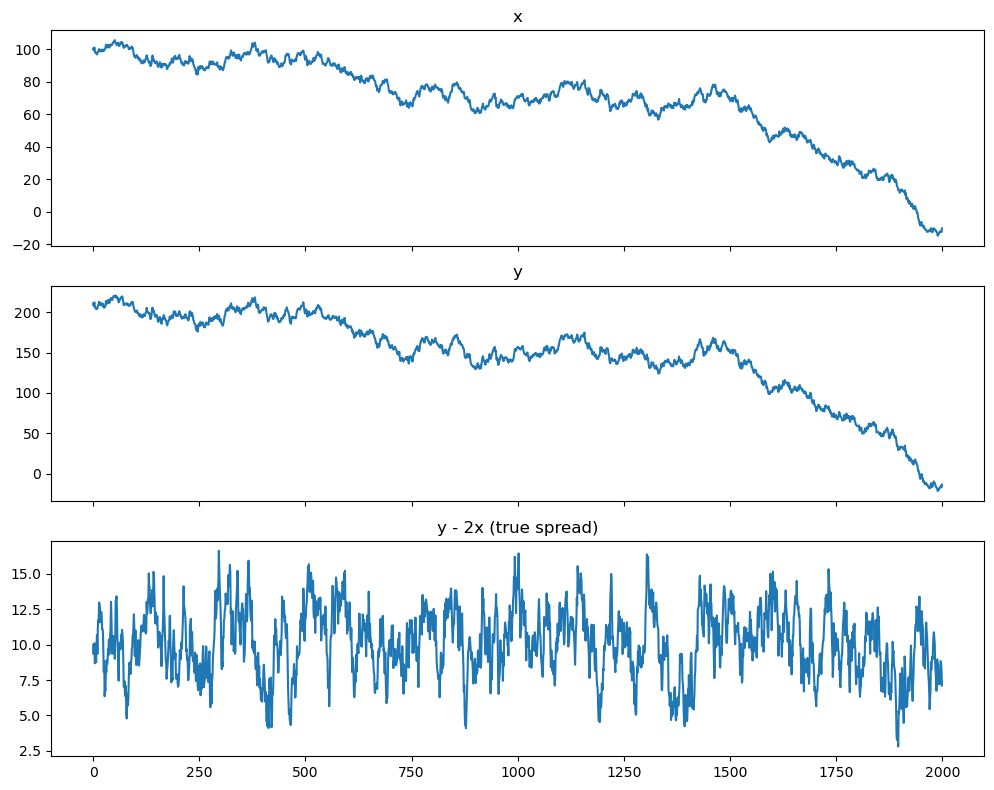

In [41]:
fig, ax = plt.subplots(3,1, figsize=(10, 8), sharex=True)
ax[0].plot(x); ax[0].set_title("x")
ax[1].plot(y); ax[1].set_title("y")
ax[2].plot(y - 2*x); ax[2].set_title("y - 2x (true spread)")
plt.tight_layout()
plt.show()

### Engle-Granger (CADF)

### **Procedure**
- Regress y on x with a constant: y = c + β·x + u. β is the hedge ratio.
- Run ADF on the residuals u (the spread).
- Compare against MacKinnon cointegration critical values, not the standard ADF ones.

In [42]:
def simulate(T, phi, rng):
    x = 100 + np.cumsum(rng.normal(0, 1, T))
    e = lfilter([1], [1, -phi], rng.normal(0, 1, T))
    y = 10 + 2 * x + e
    return x, y

def eg_manual(y, x, maxlag=1):
    res = sm.OLS(y, sm.add_constant(x)).fit()
    beta, resid = res.params[1], res.resid
    stat = adfuller(resid, maxlag=maxlag, regression="n", autolag=None)[0]
    return beta, stat

In [43]:
rng = np.random.default_rng(1)
x, y = simulate(1000, 0.9, rng)

In [44]:
beta , stat = eg_manual(y, x)
c_stat, c_p, c_crit = coint(y, x, trend="c", maxlag=1, autolag=None)

In [45]:
print("--- Part A: manual vs coint (should match) ---")
print(f"manual: beta={beta:.4f}  ADF stat={stat:.4f}")
print(f"coint : stat={c_stat:.4f}  p={c_p:.4f}  crit(1/5/10%)={np.round(c_crit, 3)}")
print(f"standard ADF 5% crit is about -2.86; EG 5% crit is {c_crit[1]:.2f}")

--- Part A: manual vs coint (should match) ---
manual: beta=1.9669  ADF stat=-7.8859
coint : stat=-7.8859  p=0.0000  crit(1/5/10%)=[-3.907 -3.342 -3.049]
standard ADF 5% crit is about -2.86; EG 5% crit is -3.34


In [46]:
b_yx = sm.OLS(y, sm.add_constant(x)).fit().params[1]
b_xy = sm.OLS(x, sm.add_constant(y)).fit().params[1]

In [47]:
print("\n--- Part B: order dependence ---")
print(f"y on x: beta={b_yx:.4f}")
print(f"x on y: beta={b_xy:.4f}  -> implied y-on-x ratio = {1/b_xy:.4f}")
print(f"beta_yx * beta_xy = R^2 = {b_yx*b_xy:.4f}")
print(f"coint(y,x) stat={coint(y,x,maxlag=1,autolag=None)[0]:.3f}   "
      f"coint(x,y) stat={coint(x,y,maxlag=1,autolag=None)[0]:.3f}")


--- Part B: order dependence ---
y on x: beta=1.9669
x on y: beta=0.5063  -> implied y-on-x ratio = 1.9750
beta_yx * beta_xy = R^2 = 0.9959
coint(y,x) stat=-7.886   coint(x,y) stat=-7.853


### Part C: why the critical values matter
x and y are INDEPENDENT random walks: no cointegration exists. \
Every rejection is a false positive; a correct test rejects about 5%.

In [48]:
n_sims , T = 1000, 500
rng = np.random.default_rng(7)
naive = correct = 0
for _ in range (n_sims):
    a = np.cumsum(rng.normal(size=T))
    b = np.cumsum(rng.normal(size=T))

    _, s = eg_manual(a, b)
    naive += s < -2.86
    p = coint(a, b, maxlag=1, autolag=None)[1]
    correct += p < 0.05

In [49]:
print("\n--- Part C: false positive rate on independent random walks ---")
print(f"naive ADF on residuals (-2.86): {naive/n_sims:.1%}")
print(f"coint (MacKinnon):              {correct/n_sims:.1%}")


--- Part C: false positive rate on independent random walks ---
naive ADF on residuals (-2.86): 14.6%
coint (MacKinnon):              5.3%


## Using real data

**Idea:** instead of one regression, model all series jointly as a VAR in error-correction form. The number of cointegrating relations equals the rank r of a matrix, and the test finds it.

- Trace test: H0 is "at most r relations". Tested sequentially for r = 0, 1, ...
- Max-eigenvalue test: H0 is "exactly r" against "r+1". \
**Procedure:** compare the statistic to the critical value, moving down until you first fail to reject. That r is your estimat
- Eigenvectors: the columns of evec are the hedge ratios. The first column has the strongest mean reversion.

In [50]:
df = yf.download(["EWA", "EWC"], start="2006-04-26", end="2012-04-09", auto_adjust=True)["Close"].dropna()
df.head()

[*********************100%***********************]  2 of 2 completed


Ticker,EWA,EWC
Date,,
2006-04-26,8.892220,16.619539
2006-04-27,8.843583,16.505928
2006-04-28,8.892220,16.612852
2006-05-01,8.977333,16.686356
2006-05-02,8.969225,16.866789


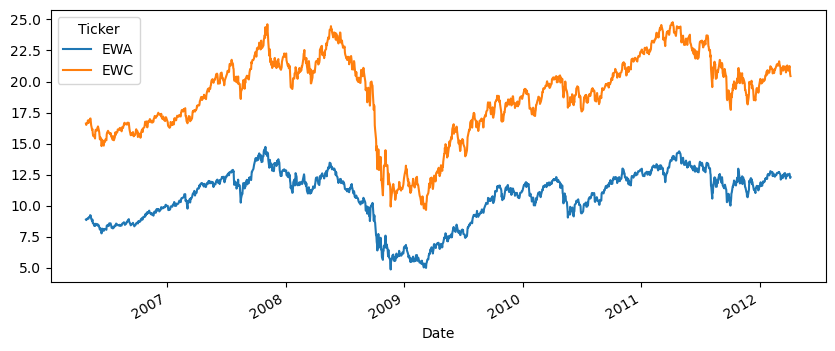

In [51]:
df.plot(figsize=(10, 4))
plt.show()

### Engle-Granger in both orders

In [52]:
x, y = df["EWA"], df["EWC"]

for name, (a,b) in {"EWC on EWA": (y, x), "EWA on EWC": (x, y)}.items():
    stat, p, crit = coint(a, b, maxlag=1, autolag=None)
    beta = sm.OLS(a, sm.add_constant(b)).fit().params.iloc[1]
    print(f"{name}: hedge ratio={beta:.3f}  stat={stat:.3f}  p={p:.3f}  5% crit={crit[1]:.3f}")

EWC on EWA: hedge ratio=1.476  stat=-3.645  p=0.022  5% crit=-3.340
EWA on EWC: hedge ratio=0.624  stat=-3.649  p=0.021  5% crit=-3.340


### Johansen

In [53]:
r = coint_johansen(df.values, 0, 1)
print("trace stats:", r.lr1.round(2))
print("95% crit   :", r.cvt[:, 1].round(2))
print("eigvec 0   :", r.evec[:, 0] / r.evec[0, 0])

trace stats: [20.17  3.9 ]
95% crit   : [15.49  3.84]
eigvec 0   : [ 1.         -0.65243129]


| Hypothesis | Trace Stat | 95% cutoff | verdict |
|----------|----------|----------|----------|
| r=0 (no relation)  | 20.17   | 15.49   | reject |
| r $\leq$ 1 (at most one)  | 3.9   | 3.84   | reject, barely |


**The hedge ratio** \
The eigenvector [1, -0.652] means: long 1 unit of EWA, short 0.652 units of EWC. Check it against Step 2: EWA on EWC gave 0.624, and Johansen gives 0.652. Close, as they should be.

### checking rank-2 claim

In [54]:
for name in ["EWA", "EWC"]:
    print(name, "ADF p-value:", round(adfuller(df[name], maxlag=1, autolag=None)[1],3))

EWA ADF p-value: 0.353
EWC ADF p-value: 0.34


### Half-life of mean reversion
$Δs_t = λ · s_{t-1} + c + noise$

λ must be negative for mean reversion. Positive or near zero means no reversion.
Half-life = -ln(2) / λ, the number of days for a deviation to decay by half.

In [55]:
spread = df["EWA"] - 0.652 * df["EWC"]

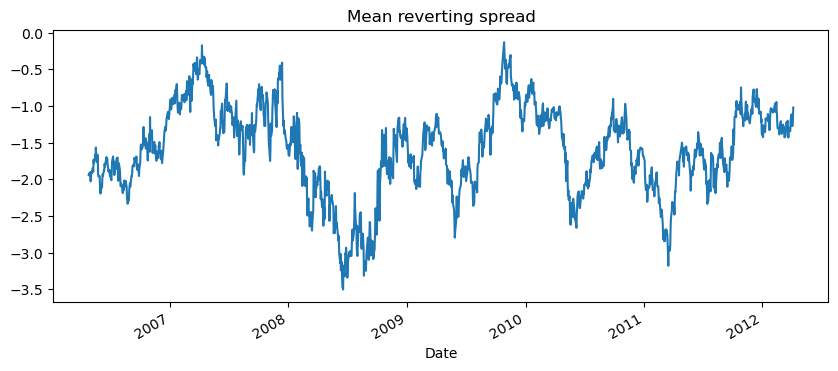

In [56]:
spread.plot(figsize=(10, 4))
plt.title("Mean reverting spread")
plt.show()

In [57]:
lag = spread.shift(1).iloc[1:]
delta = spread.diff().iloc[1:]
fit = sm.OLS(delta, sm.add_constant(lag)).fit()
lam = fit.params.iloc[1]

In [58]:
print("lambda:", round(lam, 5))
print("t-stat:", round(fit.tvalues.iloc[1], 2))
print("half-life (days):", round(-np.log(2) / lam, 1))

lambda: -0.02511
t-stat: -4.34
half-life (days): 27.6


### linear mean reverting strategy

In [69]:
K, HR, LB = 100_000, 0.652, 28

sp = df["EWA"] - HR * df["EWC"]
zf = (sp - sp.rolling(LB).mean()) / sp.rolling(LB).std()
gross_unit = df["EWA"] + HR * df["EWC"]
u = -zf.clip(-3, 3) * (K / 3) / gross_unit          # spread units held

assert u.notna().sum() > 1400, "warm-up should only drop ~28 rows"
assert u.abs().max() > 100, "u should be in shares (hundreds+), not z-scores"

pnl_f = (u.shift(1) * (df["EWA"].diff() - HR * df["EWC"].diff())).dropna()
chk = (u.shift(1) * sp.diff()).dropna()
print("max abs diff:", (pnl_f - chk).abs().max())   # expect ~1e-10 or smaller

eq = K + pnl_f.cumsum()
sharpe = np.sqrt(252) * (pnl_f / K).mean() / (pnl_f / K).std()
print("Sharpe:", round(sharpe, 2))
print(f"total P&L: ${pnl_f.sum():,.0f} ({pnl_f.sum()/K:.1%} of K)")
print(f"max drawdown: ${(eq - eq.cummax()).min():,.0f}")
print(pnl_f.groupby(pnl_f.index.year).sum().round(0))

max abs diff: 5.6843418860808015e-12
Sharpe: 1.45
total P&L: $39,723 (39.7% of K)
max drawdown: $-3,496
Date
2006     4660.0
2007     8510.0
2008    19075.0
2009      946.0
2010     2075.0
2011     3033.0
2012     1424.0
dtype: float64


In [70]:
traded = (u * df["EWA"]).diff().abs() + (u * HR * df["EWC"]).diff().abs()   # $ traded each day

for bps in (0, 2, 5, 10):
    cost = (traded * bps / 1e4).reindex(pnl_f.index)
    net = pnl_f - cost
    sh = np.sqrt(252) * (net / K).mean() / (net / K).std()
    print(f"bps={bps:>2}  Sharpe={sh:5.2f}  total=${net.sum():>9,.0f}")

print("avg $ traded per day:", round(traded.reindex(pnl_f.index).mean()), " =", 
      round(traded.reindex(pnl_f.index).mean() / K, 3), "x K")

bps= 0  Sharpe= 1.45  total=$   39,723
bps= 2  Sharpe= 1.28  total=$   34,885
bps= 5  Sharpe= 1.02  total=$   27,628
bps=10  Sharpe= 0.58  total=$   15,533
avg $ traded per day: 16444  = 0.164 x K
